Alishba Bacha  2022088

AI-351 Assignment 01

In [2]:
import pandas as pd
df=pd.read_csv('/content/top_rated_9000_movies_on_TMDB.csv')
df.head()

,id,title,original_language,release_date,vote_average,vote_count,popularity,overview,genre_ids,Genres
0,278,The Shawshank Redemption,en,1994-09-23,8.706,26840,150.307,Imprisoned in the 1940s for the double murder ...,"[18, 80]","['Drama', 'Crime']"
1,238,The Godfather,en,1972-03-14,8.690,20373,122.973,"Spanning the years 1945 to 1955, a chronicle o...","[18, 80]","['Drama', 'Crime']"
2,240,The Godfather Part II,en,1974-12-20,8.575,12291,94.204,In the continuing saga of the Corleone crime f...,"[18, 80]","['Drama', 'Crime']"
3,424,Schindler's List,en,1993-12-15,8.565,15695,74.615,The true story of how businessman Oskar Schind...,"[18, 36, 10752]","['Drama', 'History', 'War']"
4,389,12 Angry Men,en,1957-04-10,8.546,8522,54.678,The defense and the prosecution have rested an...,[18],['Drama']


**1: Data Preprocessing**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9630 entries, 0 to 9629
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 9630 non-null   int64  
 1   title              9630 non-null   object 
 2   original_language  9630 non-null   object 
 3   release_date       9630 non-null   object 
 4   vote_average       9630 non-null   float64
 5   vote_count         9630 non-null   int64  
 6   popularity         9630 non-null   float64
 7   overview           9630 non-null   object 
 8   genre_ids          9630 non-null   object 
 9   Genres             9630 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 752.5+ KB


In [ ]:
df.isnull().sum()

,0
id,0
title,0
original_language,0
release_date,0
vote_average,0
vote_count,0
popularity,0
overview,0
genre_ids,0
Genres,0


        **A) Handling Missing values and Dealing with outliers**

In [3]:
import numpy as np

# Calculate Z-scores for numerical columns
from scipy import stats

# Count outliers using Z-score for multiple columns
def count_outliers_zscore(df, column):
    z_scores = np.abs(stats.zscore(df[column]))
    threshold = 3
    return np.sum(z_scores > threshold)

outliers_id_count = count_outliers_zscore(df, 'id')
outliers_vote_average_count = count_outliers_zscore(df, 'vote_average')
outliers_vote_count_count = count_outliers_zscore(df, 'vote_count')
outliers_popularity_count = count_outliers_zscore(df, 'popularity')

print(f"ID Outliers: {outliers_id_count}")
print(f"Vote Average Outliers: {outliers_vote_average_count}")
print(f"Vote Count Outliers: {outliers_vote_count_count}")
print(f"Popularity Outliers: {outliers_popularity_count}")

ID Outliers: 114
Vote Average Outliers: 47
Vote Count Outliers: 247
Popularity Outliers: 55


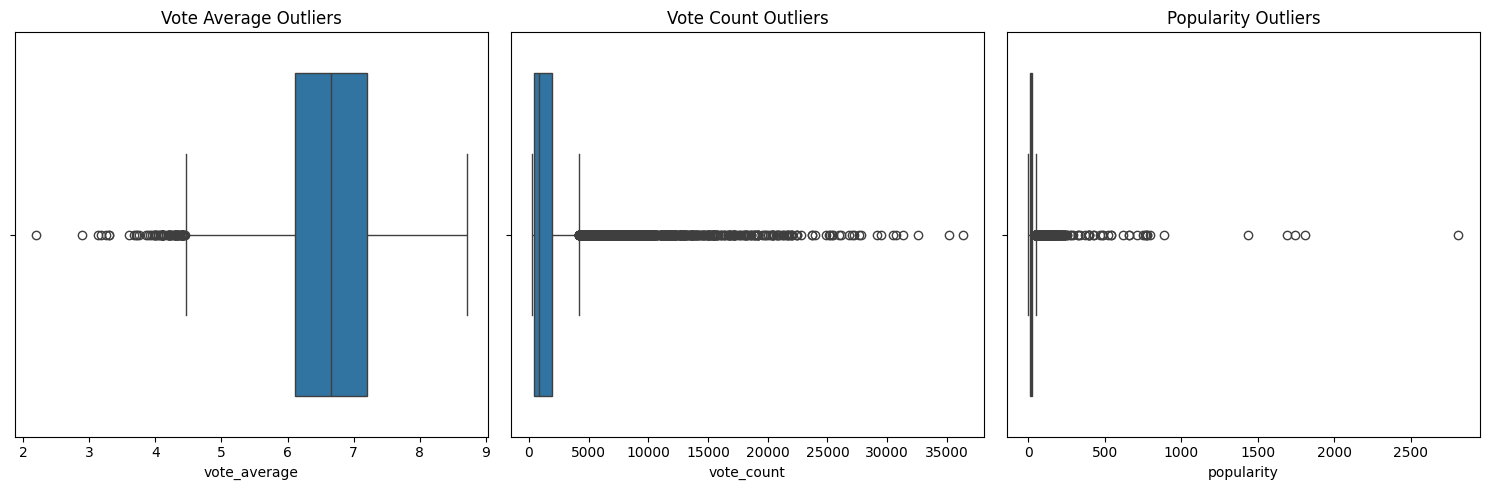

In [4]:
#plot outliers
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Vote Average
sns.boxplot(ax=axes[0], x=df['vote_average'])
axes[0].set_title('Vote Average Outliers')

# Vote Count
sns.boxplot(ax=axes[1], x=df['vote_count'])
axes[1].set_title('Vote Count Outliers')

# Popularity
sns.boxplot(ax=axes[2], x=df['popularity'])
axes[2].set_title('Popularity Outliers')

plt.tight_layout()
plt.show()


In [ ]:
# Dealing with outliers
numerical_columns = ['id', 'vote_average', 'vote_count', 'popularity']

for col in numerical_columns:
    z_scores = np.abs((df[col] - df[col].mean()) / df[col].std())
    df = df[z_scores<=3]

In [ ]:
# Cap outliers
for col in numerical_columns:
    lower_bound = df[col].quantile(0.01)
    upper_bound = df[col].quantile(0.99)
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound,df[col])

In [ ]:
# Log transformation (ensure there are no zero or negative values)
for col in numerical_columns:
    df[col] = np.log(df[col] + 1)  # Adding 1 to avoid log(0)

In [ ]:
import numpy as np

# Initialize a dictionary to store outlier counts
outlier_counts_z = {}

# Calculate Z-scores and count outliers for each numerical column
numerical_columns = ['id', 'vote_average', 'vote_count', 'popularity']
for col in numerical_columns:
    z_scores = np.abs((df[col] - df[col].mean()) / df[col].std())
    outlier_count = (z_scores > 3).sum()  # Count of outliers
    outlier_counts_z[col] = outlier_count

print("Outlier counts using Z-score method:")
for col, count in outlier_counts_z.items():
    print(f"{col}: {count} outliers")

Outlier counts using Z-score method:
id: 0 outliers
vote_average: 0 outliers
vote_count: 0 outliers
popularity: 0 outliers


In [ ]:
# Summary statistics
df.describe()


,id,vote_average,vote_count,popularity
count,9184.000000,9184.000000,9184.000000,9184.000000
mean,10.604634,2.025869,6.904306,2.869232
std,2.151344,0.099364,0.908196,0.579682
min,5.229289,1.743206,5.720312,1.785560
25%,9.223824,1.960095,6.142037,2.452125
50%,10.437668,2.032874,6.708084,2.784023
75%,12.743988,2.101203,7.504942,3.199917
max,13.684102,2.216719,9.170565,4.601822


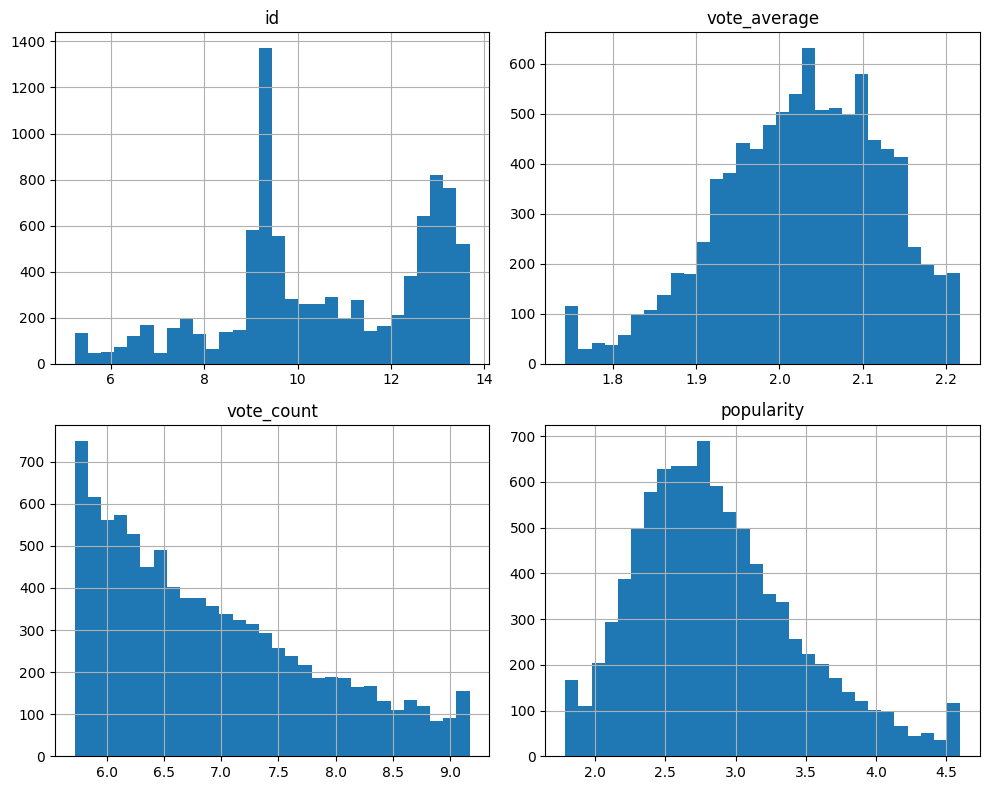

In [ ]:
import matplotlib.pyplot as plt

# Plot histograms for numerical features
df[['id','vote_average', 'vote_count', 'popularity']].hist(bins=30, figsize=(10, 8), layout=(2, 2))
plt.tight_layout()
plt.show()


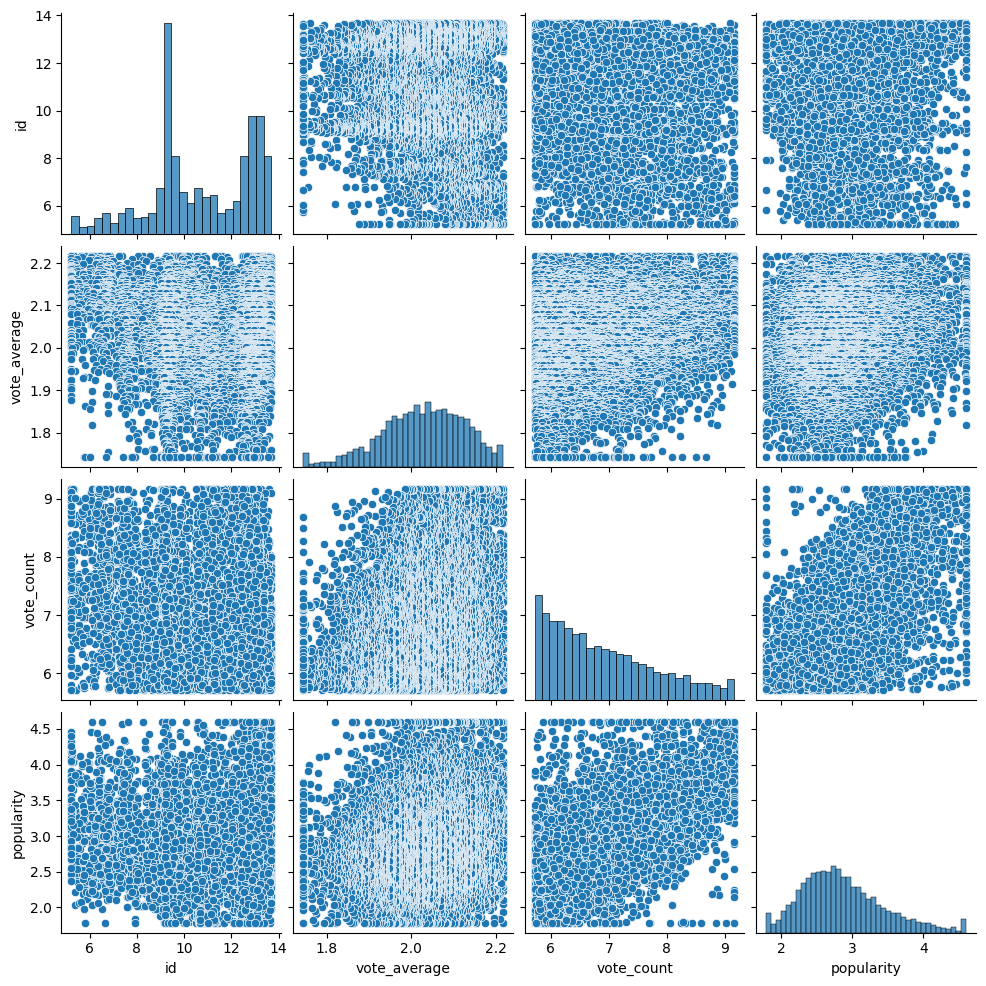

In [ ]:
import seaborn as sns

# Pair plot for important numerical columns
sns.pairplot(df[['id','vote_average', 'vote_count', 'popularity']])
plt.show()


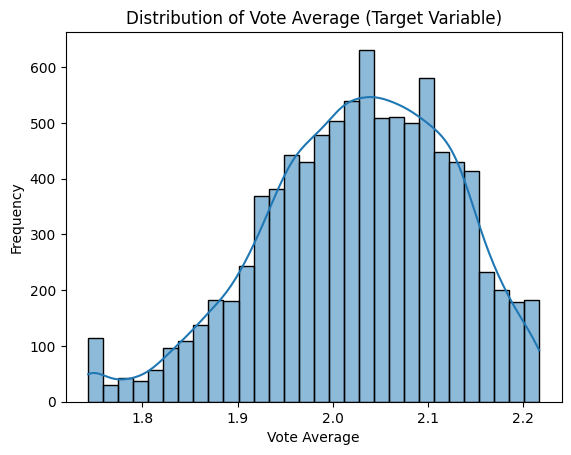

In [ ]:
#  target variable 'vote_average' for regression
sns.histplot(df['vote_average'], bins=30, kde=True)
plt.title('Distribution of Vote Average (Target Variable)')
plt.xlabel('Vote Average')
plt.ylabel('Frequency')
plt.show()


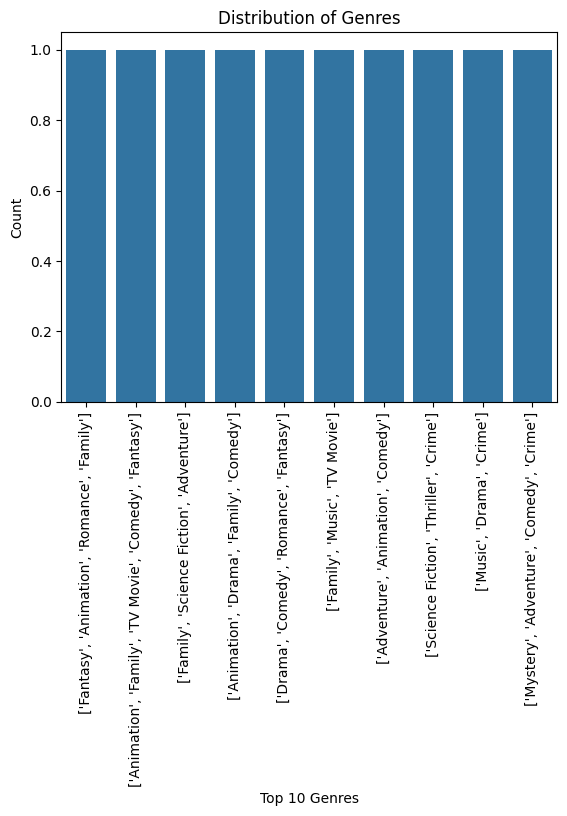

In [ ]:
# Count plot for classification target variable
plt.xticks(rotation=90)
top_genres = df['Genres'].value_counts().tail(10)
df_top_genres = df[df['Genres'].isin(top_genres.index)]
sns.countplot(x='Genres', data=df_top_genres)
plt.title('Distribution of Genres')
plt.xlabel('Top 10 Genres')
plt.ylabel('Count')
plt.show()


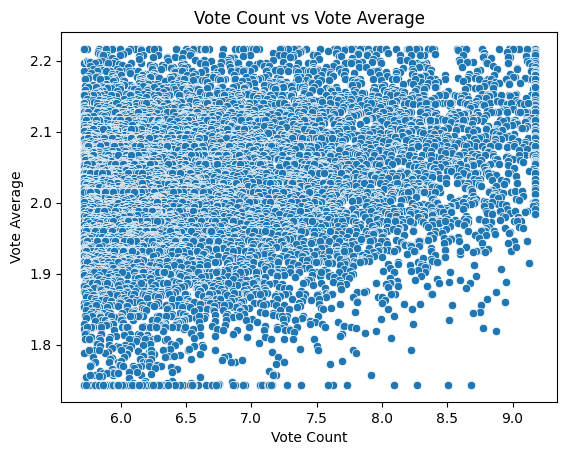

In [ ]:
# Scatter plot between 'vote_count' and 'vote_average'
sns.scatterplot(x=df['vote_count'], y=df['vote_average'])
plt.title('Vote Count vs Vote Average')
plt.xlabel('Vote Count')
plt.ylabel('Vote Average')
plt.show()


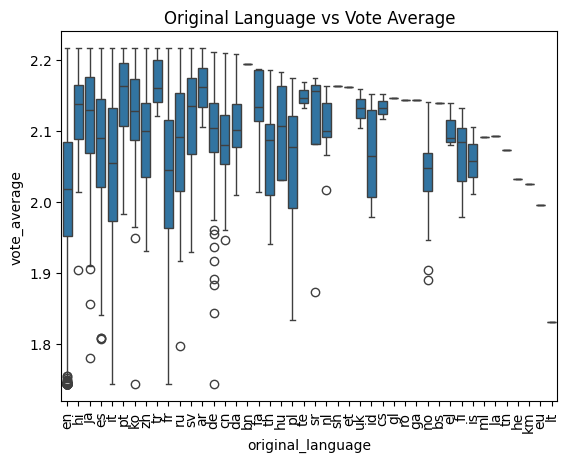

In [ ]:
# Box plot for 'original_language' vs 'vote_average'
sns.boxplot(x=df['original_language'], y=df['vote_average'])
plt.title('Original Language vs Vote Average')
plt.xticks(rotation=90)
plt.show()


**Feature Selection And Engineering**

**A)Correlation Analysis**

In [ ]:
# Calculate the correlation matrix, considering only numeric columns
correlation_matrix = df.select_dtypes(include=np.number).corr()

# Display the correlation matrix
correlation_matrix

,id,vote_average,vote_count,popularity
id,1.000000,-0.107356,-0.143408,-0.060210
vote_average,-0.107356,1.000000,0.201721,0.150015
vote_count,-0.143408,0.201721,1.000000,0.616524
popularity,-0.060210,0.150015,0.616524,1.000000


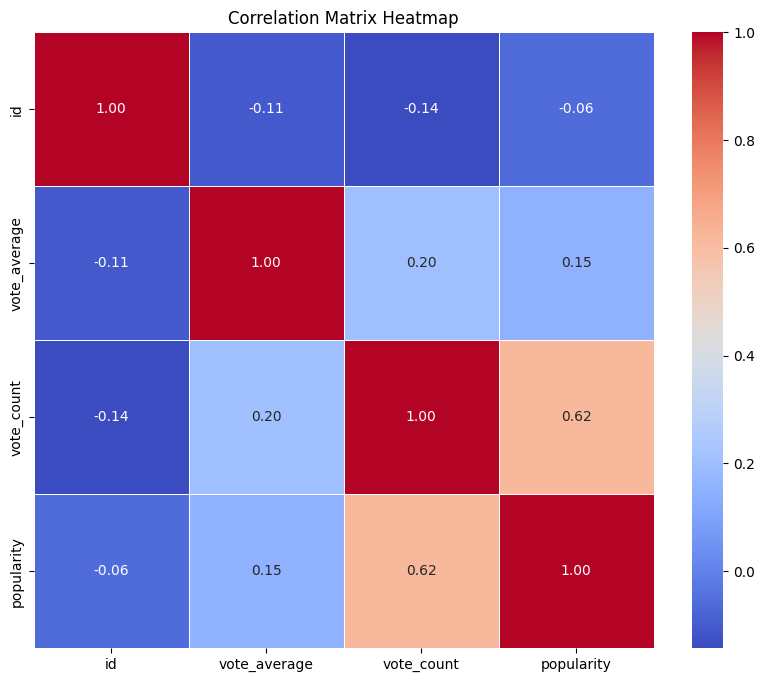

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Generate a heatmap for the correlation matrix
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# Show the plot
plt.title('Correlation Matrix Heatmap')
plt.show()


**B)Entropy And Information Gain:**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from collections import Counter
# Calculate entropy for the target column
def entropy(column):
    counts = np.bincount(column)
    probabilities = counts / len(column)
    entropy_value = -np.sum([p * np.log2(p) for p in probabilities if p > 0])
    return entropy_value

# Encoding the target labels
label_encoder = LabelEncoder()
df['original_language_encoded'] = label_encoder.fit_transform(df['original_language'])

# Calculate entropy
target_entropy = entropy(df['original_language_encoded'].values)
print(f'Entropy of the target (original_language): {target_entropy}')


Entropy of the target (original_language): 1.4572290252874391


In [ ]:
# Calculate Information Gain for a feature
def information_gain(df, split_attribute_name, target_name):
    #entropy of the full dataset
    total_entropy = entropy(df[target_name].values)

    # Variables to store weighted entropy and information gain
    vals, counts = np.unique(df[split_attribute_name], return_counts=True)
    weighted_entropy = 0

    # Calculate weighted entropy for each value in the feature
    for i in range(len(vals)):
        subset = df[df[split_attribute_name] == vals[i]]
        weighted_entropy += (counts[i] / np.sum(counts)) * entropy(subset[target_name].values)

    # Information Gain is the difference between total entropy and weighted entropy
    information_gain_value = total_entropy - weighted_entropy
    return information_gain_value

In [ ]:
# List of features to calculate Information Gain
features = ['vote_average', 'vote_count', 'popularity']

# Information Gain for each feature
for feature in features:
    ig = information_gain(df, feature, 'original_language_encoded')
    print(f'Information Gain for {feature}: {ig}')


Information Gain for vote_average: 0.8093302790072932
Information Gain for vote_count: 0.7054231640160928
Information Gain for popularity: 1.3215001692109056


**Supervise Regression Task**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Handling missing values (if any)
df.fillna(0, inplace=True)

# Features: Using 'vote_count', 'popularity'
X = df[['vote_count', 'popularity']]
y = df['vote_average']

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the linear regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Predictions
y_pred_linear = linear_model.predict(X_test)

# Evaluation: Mean Squared Error and R-squared
mse = mean_squared_error(y_test, y_pred_linear)
r2 = r2_score(y_test,y_pred_linear)

print(f"Linear Regression MSE: {mse}")
print(f"Linear Regression R²: {r2}")


Linear Regression MSE: 0.0098743234856395
Linear Regression R²: 0.03600502343474765


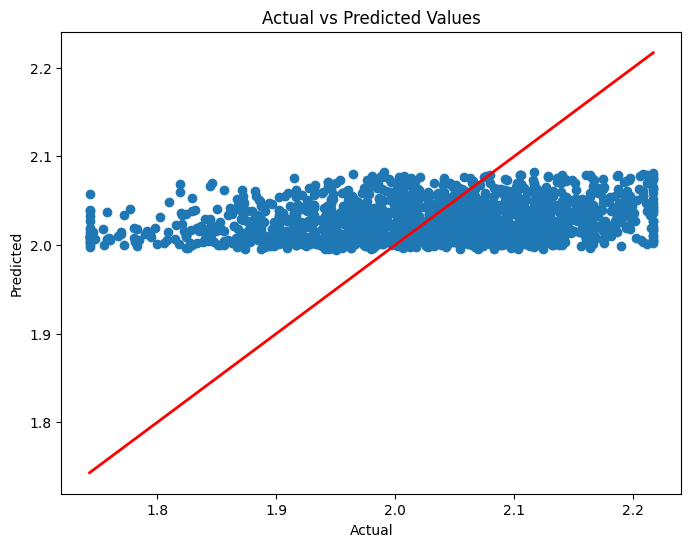

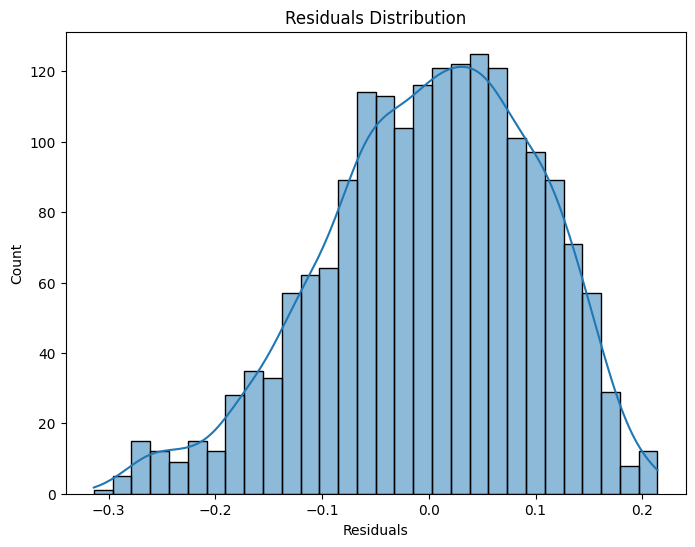

In [ ]:
# Plot the actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_linear)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2) # perfect fit line
plt.title('Actual vs Predicted Values')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

# Residual analysis (difference between actual and predicted)
residuals = y_test - y_pred_linear

# Plot residuals
plt.figure(figsize=(8, 6))
sns.histplot(residuals, bins=30, kde=True)
plt.title('Residuals Distribution')
plt.xlabel('Residuals')
plt.show()


In [ ]:
from sklearn.linear_model import Ridge

# Apply Ridge regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

# Predictions
y_pred_ridge = ridge_model.predict(X_test)

# Evaluation: MSE and R² for Ridge Regression
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Ridge Regression MSE: {mse_ridge}")
print(f"Ridge Regression R²: {r2_ridge}")


Ridge Regression MSE: 0.00987431649543072
Ridge Regression R²: 0.03600570586389418


In [ ]:
from sklearn.linear_model import Lasso

# Apply Lasso regression
lasso_model = Lasso(alpha=0.1)  # alpha controls the regularization strength
lasso_model.fit(X_train, y_train)

# Predictions
y_pred_lasso = lasso_model.predict(X_test)

# Evaluation: MSE and R² for Lasso Regression
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"Lasso Regression MSE: {mse_lasso}")
print(f"Lasso Regression R²: {r2_lasso}")


Lasso Regression MSE: 0.010243271381410877
Lasso Regression R²: -1.404345678990282e-05


In [ ]:
print(f"Linear Regression MSE: {mse}")
print(f"Linear Regression R²: {r2}")

print(f"Ridge Regression MSE: {mse_ridge}")
print(f"Ridge Regression R²: {r2_ridge}")

print(f"Lasso Regression MSE: {mse_lasso}")
print(f"Lasso Regression R²: {r2_lasso}")


Linear Regression MSE: 0.0098743234856395
Linear Regression R²: 0.03600502343474765
Ridge Regression MSE: 0.00987431649543072
Ridge Regression R²: 0.03600570586389418
Lasso Regression MSE: 0.010243271381410877
Lasso Regression R²: -1.404345678990282e-05


**supervise Classification Task**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Binary classification target
df['profitable'] = np.where(df['popularity'] > 3, 1, 0)

# Features: Using 'vote_count', 'vote_average', etc.
x = df[['vote_count', 'vote_average']]
y = df['profitable']

# Split the data
X_train_C, X_test_C, y_train_C, y_test_C = train_test_split(x, y, test_size=0.2, random_state=42)

# Train Logistic Regression model
log_reg = LogisticRegression()
log_reg.fit(X_train_C, y_train_C)

# Predictions
y_pred_C = log_reg.predict(X_test_C)

# Evaluation
accuracy = accuracy_score(y_test_C, y_pred_C)
conf_matrix = confusion_matrix(y_test_C, y_pred_C)
classification_rep = classification_report(y_test_C, y_pred_C)

print(f"Logistic Regression Accuracy: {accuracy}")
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Classification Report:\n{classification_rep}")


Logistic Regression Accuracy: 0.7866086009798585
Confusion Matrix:
[[1054  119]
 [ 273  391]]
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.90      0.84      1173
           1       0.77      0.59      0.67       664

    accuracy                           0.79      1837
   macro avg       0.78      0.74      0.75      1837
weighted avg       0.78      0.79      0.78      1837



In [ ]:
# Coefficients of the logistic regression model
coefficients = log_reg.coef_
print(f"Feature coefficients: {coefficients}")


Feature coefficients: [[1.55375041 0.43611858]]


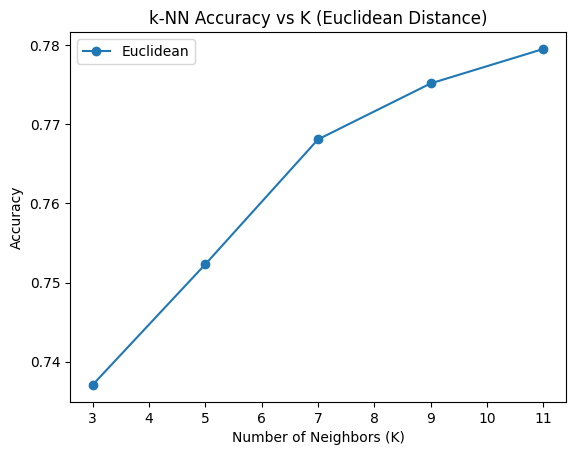

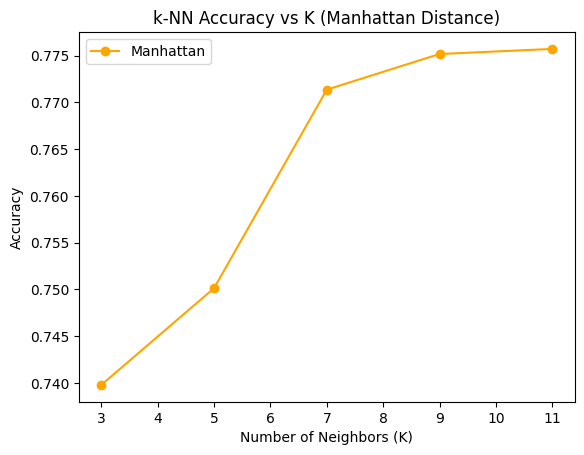

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

# Function to train and evaluate k-NN for different values of k
def knn_performance(k_values, X_train, y_train, X_test, y_test, metric='euclidean'):
    accuracy_scores = []
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        knn.fit(X_train, y_train)
        y_pred_knn = knn.predict(X_test)
        accuracy_scores.append(accuracy_score(y_test, y_pred_knn))
    return accuracy_scores

# Different values of k
k_values = [3, 5, 7, 9, 11]

# Evaluate using Euclidean distance
euclidean_accuracies = knn_performance(k_values, X_train_C ,y_train_C, X_test_C, y_test_C, metric='euclidean')

# Plot accuracy vs k for Euclidean distance
plt.plot(k_values, euclidean_accuracies, marker='o', label='Euclidean')
plt.title('k-NN Accuracy vs K (Euclidean Distance)')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Compare with Manhattan distance
manhattan_accuracies = knn_performance(k_values, X_train_C, y_train_C, X_test_C, y_test_C, metric='manhattan')

# Plot accuracy vs k for Manhattan distance
plt.plot(k_values, manhattan_accuracies, marker='o', label='Manhattan', color='orange')
plt.title('k-NN Accuracy vs K (Manhattan Distance)')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


Decision Tree Accuracy: 0.6978769733260751


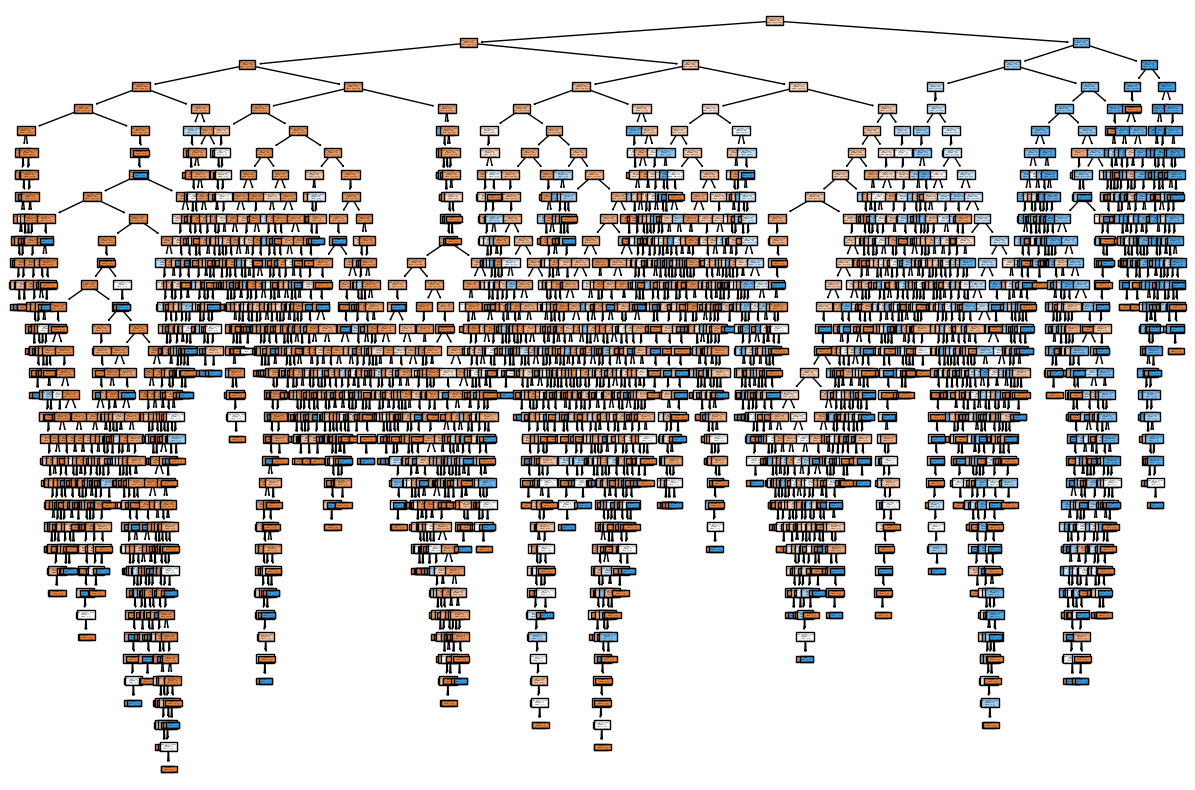

Pruned Decision Tree Accuracy: 0.7855198693522046


In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Train a Decision Tree classifier
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train_C, y_train_C)

# Predictions
y_pred_tree = tree_model.predict(X_test_C)

# Evaluation
accuracy_tree = accuracy_score(y_test_C, y_pred_tree)
print(f"Decision Tree Accuracy: {accuracy_tree}")

# Visualize the tree
plt.figure(figsize=(15, 10))
plot_tree(tree_model, filled=True, feature_names=['vote_count', 'vote_average'], class_names=['Not Profitable', 'Profitable'])
plt.show()

# Apply pruning (set max_depth to avoid overfitting)
pruned_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
pruned_tree.fit(X_train_C, y_train_C)
y_pred_pruned = pruned_tree.predict(X_test_C)

# Evaluate pruned tree
accuracy_pruned = accuracy_score(y_test_C, y_pred_pruned)
print(f"Pruned Decision Tree Accuracy: {accuracy_pruned}")


In [ ]:
from sklearn.preprocessing import StandardScaler

# Standardize features
scaler = StandardScaler()
X_train_C_scaled = scaler.fit_transform(X_train_C)
X_test_C_scaled = scaler.transform(X_test_C)


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Ensure that feature scaling is applied
scaler = StandardScaler()
X_train_C_scaled = scaler.fit_transform(X_train_C)
X_test_C_scaled = scaler.transform(X_test_C)

# Linear kernel SVM
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train_C_scaled, y_train_C)

# Predictions and evaluation for linear kernel
y_pred_svm_linear = svm_linear.predict(X_test_C_scaled)
accuracy_svm_linear = accuracy_score(y_test_C, y_pred_svm_linear)
print(f"SVM (Linear Kernel) Accuracy: {accuracy_svm_linear}")

# RBF kernel SVM
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train_C_scaled, y_train_C)

# Predictions and evaluation for RBF kernel
y_pred_svm_rbf = svm_rbf.predict(X_test_C_scaled)
accuracy_svm_rbf = accuracy_score(y_test_C, y_pred_svm_rbf)
print(f"SVM (RBF Kernel) Accuracy: {accuracy_svm_rbf}")

# Polynomial kernel SVM
svm_poly = SVC(kernel='poly', degree=3)
svm_poly.fit(X_train_C_scaled, y_train_C)

# Predictions and evaluation for polynomial kernel
y_pred_svm_poly = svm_poly.predict(X_test_C_scaled)
accuracy_svm_poly = accuracy_score(y_test_C, y_pred_svm_poly)
print(f"SVM (Polynomial Kernel) Accuracy: {accuracy_svm_poly}")


SVM (Linear Kernel) Accuracy: 0.7882416984213392
SVM (RBF Kernel) Accuracy: 0.7827980402830702
SVM (Polynomial Kernel) Accuracy: 0.7544910179640718


**Model Evaluation + Overfitting/ Underfitting**

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from sklearn.linear_model import LinearRegression # Import LinearRegression

# Initialize and train the Linear Regression model
linear_reg = LinearRegression()  # Create a LinearRegression object
linear_reg.fit(X_train, y_train)  # Fit the model to your training data

# Example predictions for Linear Regression (y_pred is already calculated in previous steps)
y_pred_linear = linear_reg.predict(X_test)

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred_linear)

# Root Mean Squared Error
rmse = np.sqrt(mse)

# R-squared
r_squared = r2_score(y_test, y_pred_linear)

print(f"Linear Regression MSE: {mse}")
print(f"Linear Regression RMSE: {rmse}")
print(f"Linear Regression R-squared: {r_squared}")

Linear Regression MSE: 0.0098743234856395
Linear Regression RMSE: 0.09936963060029709
Linear Regression R-squared: 0.03600502343474765


Confusion Matrix:
[[1054  119]
 [ 273  391]]
Accuracy: 0.7866086009798585
Precision: 0.7666666666666667
Recall: 0.588855421686747
F1-Score: 0.666098807495741
AUC: 0.8186621164966774


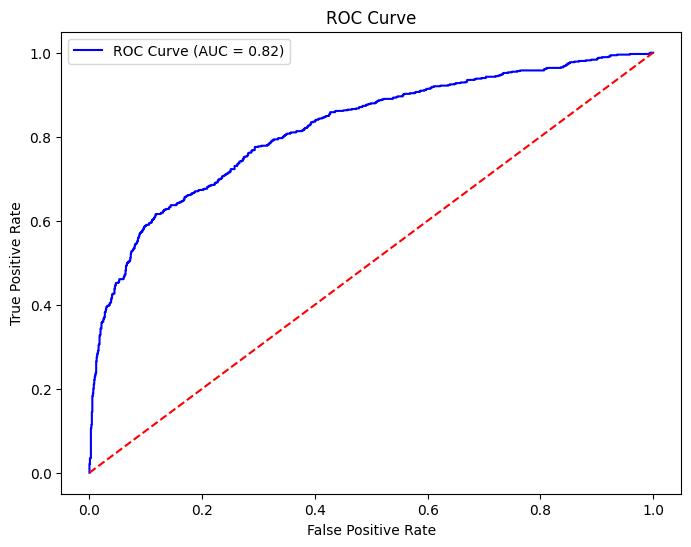

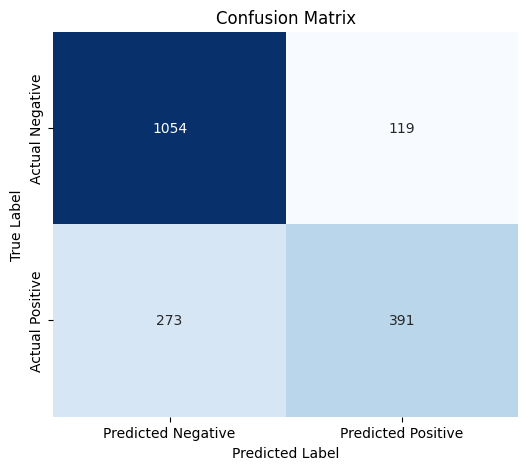

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Example predictions for Logistic Regression (y_pred is already calculated in previous steps)
y_pred_class = log_reg.predict(X_test_C)
y_prob_class = log_reg.predict_proba(X_test_C)[:, 1]  # Probabilities for ROC

# Confusion Matrix
conf_matrix = confusion_matrix(y_test_C, y_pred_class)

# Accuracy
accuracy = accuracy_score(y_test_C, y_pred_class)

# Precision, Recall, F1-Score
precision = precision_score(y_test_C, y_pred_class)
recall = recall_score(y_test_C, y_pred_class)
f1 = f1_score(y_test_C, y_pred_class)

# ROC Curve and AUC
fpr, tpr, _ = roc_curve(y_test_C, y_prob_class)
auc = roc_auc_score(y_test_C, y_prob_class)

# Print evaluation metrics
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")
print(f"AUC: {auc}")

# Plot ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Plot Confusion Matrix as heatmap
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
